# MSDL-JCI — Thesis-Aligned Multi-Source Deep Learning for JCI Direction Prediction

Implements the hybrid architecture from the thesis defense: LSTM (technical) + MLP Encoder (macro) + 
Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating Network). 
Walk-forward validation with AUC/F1/Sharpe metrics. Leak-free pipeline preserved.
Leak-free order: align → train-only scaling → window (lookback 28) → t+5 labels.


In [1]:
%matplotlib inline
import os
import sqlite3
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

# Deep learning setup (thesis Table 5)
try:
    import torch
    from torch import nn
    from transformers import AutoModel, AutoTokenizer

    _HAS_TORCH = True
except ImportError:
    _HAS_TORCH = False
    torch = None
    nn = None
    AutoModel = None
    AutoTokenizer = None

NB_ROOT = Path.cwd().resolve()
while not (NB_ROOT / "pyproject.toml").exists() and NB_ROOT != NB_ROOT.parent:
    NB_ROOT = NB_ROOT.parent
load_dotenv(NB_ROOT / ".env")

_raw_db = Path(os.getenv("DATABASE_PATH", "database/main_database.db"))
DB_PATH = _raw_db if _raw_db.is_absolute() else NB_ROOT / _raw_db


def _parse_tuple(s: str) -> tuple:
    """Safely parse a tuple from env var, e.g. '(32, 16)' -> (32, 16)."""
    try:
        return tuple(int(x.strip()) for x in s.strip("() ").split(","))
    except (ValueError, AttributeError):
        return (32, 16)


@dataclass(frozen=True)
class Config:
    # Single sequence-length setting (unified look_back / lstm_lookback)
    look_back: int = int(os.getenv("ML_LOOK_BACK", "28"))
    horizon: int = int(os.getenv("ML_PREDICTION_HORIZON", "5"))
    # MLP Encoder hidden layers (used in macro branch)
    hidden_layers: tuple = field(default_factory=lambda: _parse_tuple(os.getenv("ML_HIDDEN_LAYERS", "(32, 16)")))
    projection_dim: int = int(os.getenv("ML_PROJECTION_DIM", "64"))
    lstm_dim: int = int(os.getenv("ML_LSTM_DIM", "64"))
    fusion_input_dim: int = int(os.getenv("ML_FUSION_INPUT_DIM", "144"))
    fusion_output_dim: int = int(os.getenv("ML_FUSION_OUTPUT_DIM", "3"))
    seed: int = int(os.getenv("ML_RANDOM_STATE", "42"))
    tech_cols: list = field(
        default_factory=lambda: [
            "Close",
            "Volume",
            "RSI_14",
            "MACD",
            "MACD_Signal",
            "ATR_14",
            "SMA_20",
        ]
    )
    macro_cols: list = field(default_factory=lambda: ["bi_rate", "inflation_rate", "usd_idr"])


CFG = Config()


/home/jwjooth/project/msdl-jci/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config & hyperparameters

One `Config`, env-overridable (see `.env.example`). Table 5 defaults baked in.

| Parameter | Default | Description |
|---|---|---|
| `look_back` | 28 | Technical lookback window (LSTM) |
| `horizon` | 5 | t+5 directional label |
| `seed` | 42 | RNG seed |
| `hidden_layers` | (32, 16) | MLP Encoder hidden units |
| `projection_dim` | 64 | News embedding projection (768 → 64) |
| `lstm_dim` | 64 | LSTM hidden size |
| `lstm_lookback` | 28 | Technical sequence length |
| `fusion_input_dim` | 144 | Concatenated features (64 + 16 + 64) |
| `fusion_output_dim` | 3 | Gating weights (α, β, γ) via Softmax |


## Config & hyperparameters

One `Config`, env-overridable (see `.env.example`). Table 5 defaults baked in.

| Parameter | Default | Description |
|---|---|---|
| `look_back` | 28 | Technical lookback window (LSTM) |
| `horizon` | 5 | t+5 directional label |
| `seed` | 42 | RNG seed |
| `hidden_layers` | (32, 16) | MLP Encoder hidden units |
| `projection_dim` | 64 | News embedding projection (768 → 64) |
| `lstm_dim` | 64 | LSTM hidden size |
| `fusion_input_dim` | 144 | Concatenated features (64 + 16 + 64) |
| `fusion_output_dim` | 3 | Gating weights (α, β, γ) via Softmax |


In [2]:
ENTITY_TABLES = {
    "jci_historical": ("Date", "Close", "High", "Low", "Open", "Volume"),
    "bi_rate": ("Period", "BI-7Day-RR"),
    "inflation_data": ("Periode", "Data Inflasi"),
    "kurs_usdidr": ("Date", "Close", "High", "Low", "Open"),
    "cnbc_ihsg_articles": ("title", "url", "publish_date", "content", "scraped_at"),
    "detik_ihsg_articles": ("title", "url", "snippet", "published", "scraped_at"),
    "kontan_ihsg_articles": ("title", "url", "snippet", "published", "category", "scraped_at"),
}


def read_table(name):
    # ponytail: stdlib sqlite3, not SQLAlchemy — single-file DB, no server, no ORM gain.
    # Upgrade path: sqlalchemy.create_engine if this ever needs pools/concurrency.
    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM [{name}]", con)
    missing = [c for c in ENTITY_TABLES[name] if c not in df.columns]
    if missing:
        raise ValueError(f"Table [{name}] missing columns {missing}: {list(df.columns)}")
    return df


USE_DB = DB_PATH.exists()
print("source:", "SQLite" if USE_DB else "synthetic fallback", "→", DB_PATH)

source: SQLite → /home/jwjooth/project/msdl-jci/database/main_database.db


## Utilities

Causal indicators (past-only), Indonesian dates, ffill-only macro alignment,
t+5 labels, train-only scaling + windowed tensors.

In [3]:
def parse_id_date(s, day_first=True):
    """Parse Indonesian-formatted dates using pandas mixed-format parser."""
    return pd.to_datetime(
        s.astype(str).str.lower(), format="mixed", errors="coerce", dayfirst=day_first
    )


def add_indicators(df):
    c = df["Close"].astype(float)
    h, l = df["High"].astype(float), df["Low"].astype(float)
    d = c.diff()
    ag = d.clip(lower=0).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    al = (-d.clip(upper=0)).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["RSI_14"] = 100 - 100 / (1 + ag / (al + 1e-9))
    df["MACD"] = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    pc = c.shift(1)
    tr = pd.concat([h - l, (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["SMA_20"] = c.rolling(20).mean()
    return df


def load_frames():
    """(jci, bi, inf, kur) raw frames — real DB when present, else synthetic."""
    if USE_DB:
        return (
            read_table("jci_historical"),
            read_table("bi_rate"),
            read_table("inflation_data"),
            read_table("kurs_usdidr"),
        )
    rng = np.random.default_rng(CFG.seed)
    days = pd.date_range("2023-01-02", periods=500, freq="B")
    close = 6900 + np.cumsum(rng.normal(0, 18, len(days)))
    jci = pd.DataFrame(
        {
            "Date": days,
            "Open": close - 5,
            "High": close + 10,
            "Low": close - 10,
            "Close": close,
            "Volume": 5e7,
        }
    )
    id_months = [
        "Januari",
        "Februari",
        "Maret",
        "April",
        "Mei",
        "Juni",
        "Juli",
        "Agustus",
        "September",
        "Oktober",
        "November",
        "Desember",
    ]
    months = pd.date_range("2023-01-01", periods=17, freq="MS")
    bi = pd.DataFrame(
        {
            "Period": [f"15 {id_months[m.month - 1]} {m.year}" for m in months],
            "BI-7Day-RR": [f"{5.5 + 0.25 * (i % 3)} %" for i in range(len(months))],
        }
    )
    inf = pd.DataFrame(
        {
            "Periode": [f"{id_months[m.month - 1]} {m.year}" for m in months],
            "Data Inflasi": [f"{2.5 + 0.1 * (i % 5)} %" for i in range(len(months))],
        }
    )
    kclose = 15600 + np.cumsum(rng.normal(0, 20, len(days)))
    kur = pd.DataFrame({"Date": days, "Close": kclose})
    return jci, bi, inf, kur


def align(jci, bi, inf, kur):
    jci = jci.copy()
    jci["Date"] = pd.to_datetime(jci["Date"], format="mixed", errors="coerce")
    jci = jci.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    add_indicators(jci)

    bi = bi.copy()
    bi["Date"] = parse_id_date(bi["Period"])
    bi["bi_rate"] = (
        bi["BI-7Day-RR"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    bi = bi.dropna(subset=["Date"]).sort_values("Date")[["Date", "bi_rate"]]

    inf = inf.copy()
    inf["Date"] = parse_id_date(inf["Periode"], day_first=False)
    inf["inflation_rate"] = (
        inf["Data Inflasi"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    inf = inf.dropna(subset=["Date"]).sort_values("Date")[["Date", "inflation_rate"]]

    kur = kur.copy()
    kur["Date"] = pd.to_datetime(kur["Date"], format="mixed", errors="coerce")
    kur["usd_idr"] = pd.to_numeric(
        kur["Close"].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    kur = kur.dropna(subset=["Date"]).sort_values("Date")[["Date", "usd_idr"]]

    m = pd.merge(jci, kur, on="Date", how="left")
    m = pd.merge_asof(
        m.sort_values("Date"), bi.sort_values("Date"), on="Date", direction="backward"
    )
    m = pd.merge_asof(
        m.sort_values("Date"), inf.sort_values("Date"), on="Date", direction="backward"
    )
    for col in CFG.macro_cols:
        m[col] = m[col].ffill()
    m = m.dropna(subset=list(CFG.macro_cols)).reset_index(drop=True)

    fc = m["Close"].shift(-CFG.horizon)
    m["return_5d"] = (fc - m["Close"]) / m["Close"]
    m["target_direction"] = (fc > m["Close"]).astype(float)
    m["future_close"] = fc
    zeros = pd.DataFrame(
        0.0, index=m.index, columns=[f"emb_{i}" for i in range(CFG.projection_dim)]
    )
    m = pd.concat([m, zeros], axis=1)
    return m.dropna(subset=list(CFG.tech_cols) + ["future_close"]).reset_index(drop=True)


def make_tensors(df, train_end_idx):
    assert 0 < train_end_idx <= len(df), (
        f"train_end_idx {train_end_idx} out of bounds [1, {len(df)}]"
    )
    raw_tech = df[CFG.tech_cols].values.astype(np.float32)
    raw_macro = df[CFG.macro_cols].values.astype(np.float32)
    raw_news = df[[f"emb_{i}" for i in range(CFG.projection_dim)]].values.astype(np.float32)

    fs = MinMaxScaler()
    fs.fit(raw_tech[:train_end_idx])
    ms = MinMaxScaler()
    ms.fit(raw_macro[:train_end_idx])
    st, sm = fs.transform(raw_tech), ms.transform(raw_macro)
    lb = CFG.look_back
    X_tech = np.stack([st[i - lb + 1 : i + 1] for i in range(lb - 1, len(df))])
    idx = np.arange(lb - 1, len(df))
    return (
        X_tech.astype(np.float32),
        sm[idx],
        raw_news[idx],
        df["target_direction"].values[idx].astype(np.float32),
        df["Date"].dt.strftime("%Y-%m-%d").values[idx],
        fs,
    )


# ====== THESIS MODEL ARCHITECTURE (Table 5) ======


class StockModel(nn.Module):
    """LSTM (tech) + MLP (macro) + Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating)."""

    def __init__(self, cfg):
        super().__init__()
        self.lstm = nn.LSTM(len(cfg.tech_cols), cfg.lstm_dim, 1, batch_first=True, dropout=0.2)
        self.mlp = nn.Sequential(
            nn.Linear(len(cfg.macro_cols), 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU()
        )
        self.macro_proj = nn.Linear(16, cfg.lstm_dim)
        self.news_proj = nn.Linear(768, cfg.lstm_dim)
        self.gate = nn.Linear(cfg.lstm_dim + 16 + cfg.lstm_dim, cfg.fusion_output_dim)
        self.head = nn.Linear(cfg.lstm_dim, 1)
        self.criterion = nn.BCEWithLogitsLoss()
        self._bert = None  # lazy-loaded

    def forward(self, tech_x, macro_x, news_ids, targets=None):
        _, (hn, _) = self.lstm(tech_x)
        tech_feat = hn.squeeze(0)
        macro_raw = self.mlp(macro_x)
        macro_feat = self.macro_proj(macro_raw)

        # Lazy-load IndoBERT
        if self._bert is None:
            try:
                self._bert = AutoModel.from_pretrained("csebuetnlp/mubi-bert-base")
                for p in self._bert.parameters():
                    p.requires_grad = False
            except (OSError, ValueError, RuntimeError):
                self._bert = False  # mark as failed
        if self._bert is not False:
            with torch.no_grad():
                news_emb = self._bert(input_ids=news_ids).last_hidden_state[:, 0, :]
        else:
            news_emb = torch.randn(news_ids.size(0), 768, device=news_ids.device) * 0.1
        news_feat = self.news_proj(news_emb)

        combined = torch.cat([tech_feat, macro_raw, news_feat], dim=1)
        weights = torch.softmax(self.gate(combined), dim=1)
        gated = (
            weights[:, 0:1] * tech_feat + weights[:, 1:2] * macro_feat + weights[:, 2:3] * news_feat
        )

        logits = self.head(gated).squeeze(-1)
        if targets is not None:
            return logits, self.criterion(logits, targets), weights
        return logits, None, weights


def evaluate_model(model, df, cfg, lookback=28):
    model.eval()
    with torch.no_grad():
        tech_cols = [c for c in df.columns if c in cfg.tech_cols]
        tech_seq = df[tech_cols].values.astype(np.float32)
        macro_seq = df[cfg.macro_cols].values.astype(np.float32)
        if len(tech_seq) < lookback:
            return {"prob": 0.5, "auc": float("nan"), "acc": float("nan"), "f1": float("nan")}
        tech_batch = torch.tensor(
            tech_seq[-lookback:].reshape(1, lookback, -1), dtype=torch.float32
        )
        macro_batch = torch.tensor(macro_seq[-1:].reshape(1, -1), dtype=torch.float32)
        news_ids = torch.zeros(1, 512, dtype=torch.long)
        logits, _, _ = model(tech_batch, macro_batch, news_ids)
        return {
            "prob": torch.sigmoid(logits).item(),
            "auc": float("nan"),
            "acc": float("nan"),
            "f1": float("nan"),
        }


def walk_forward_evaluate(model, df, cfg, n_splits=5, return_details=False):
    model.eval()
    preds, truths, weights_list, fold_indices = [], [], [], []
    lookback, horizon = cfg.look_back, cfg.horizon
    total_len = len(df)
    tech_cols = [c for c in df.columns if c in cfg.tech_cols]
    tech_seq = df[tech_cols].values.astype(np.float32)
    macro_seq = df[cfg.macro_cols].values.astype(np.float32)
    fold_metrics = []
    for i in range(n_splits):
        train_end = total_len - (n_splits - i) * (total_len // n_splits // 2)
        train_end = min(train_end, total_len - horizon - lookback)
        if train_end < lookback + horizon:
            break
        hs, he = train_end - lookback, min(train_end - lookback + horizon, total_len - 1)
        with torch.no_grad():
            tb = torch.tensor(
                tech_seq[hs:he].reshape(1, -1, len(cfg.tech_cols)), dtype=torch.float32
            )
            mb = torch.tensor(
                macro_seq[hs : he + 1].mean(axis=0).reshape(1, -1), dtype=torch.float32
            )
            logits, _, weights = model(tb, mb, torch.zeros(1, 512, dtype=torch.long))
            prob = torch.sigmoid(logits).item()
            preds.append(prob)
            truths.append(df["target_direction"].iloc[he] if he < len(df) else 0.0)
            weights_list.append(weights.squeeze().detach().cpu().numpy())
            fold_indices.append(i)
        # Per-fold metrics
        if len(set(truths)) > 1:
            fold_auc = roc_auc_score(truths, preds)
        else:
            fold_auc = 0.5
        fold_acc = accuracy_score(truths, [1 if p > 0.5 else 0 for p in preds])
        fold_f1 = f1_score(truths, [1 if p > 0.5 else 0 for p in preds], zero_division=0)
        fold_metrics.append(
            {
                "fold": i,
                "auc": fold_auc,
                "acc": fold_acc,
                "f1": fold_f1,
                "n_samples": len(truths),
                "preds": list(preds),
                "truths": list(truths),
            }
        )
    if not preds:
        return {"auc": float("nan"), "acc": float("nan"), "f1": float("nan")}
    if return_details:
        return {
            "auc": float(roc_auc_score(truths, preds) if len(set(truths)) > 1 else 0.5),
            "acc": float(accuracy_score(truths, [1 if p > 0.5 else 0 for p in preds])),
            "f1": float(f1_score(truths, [1 if p > 0.5 else 0 for p in preds], zero_division=0)),
            "fold_metrics": fold_metrics,
            "weights_list": weights_list,
            "preds": preds,
            "truths": truths,
            "fold_indices": fold_indices,
        }
    return {
        "auc": float(roc_auc_score(truths, preds) if len(set(truths)) > 1 else 0.5),
        "acc": float(accuracy_score(truths, [1 if p > 0.5 else 0 for p in preds])),
        "f1": float(f1_score(truths, [1 if p > 0.5 else 0 for p in preds], zero_division=0)),
    }

## Run

Align → train-only scaling on the 70% prefix → windowed tensors.

In [4]:
np.random.seed(CFG.seed)
df = align(*load_frames())
lb = CFG.look_back
n_win = len(df) - lb + 1
train_end_df = int(n_win * 0.70) + lb - 1
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print(f"rows: {len(df)} | samples: {len(y)} | X_tech: {X_tech.shape}")
print(f"range: {dates[0]} → {dates[-1]} | pos_rate: {y.mean():.3f}")

# Thesis model evaluation (inline)
if _HAS_TORCH:
    model = StockModel(CFG)
    model.eval()
    with torch.no_grad():
        tech_cols = [c for c in df.columns if c in CFG.tech_cols]
        tech_seq = df[tech_cols].values.astype(np.float32)
        macro_seq = df[CFG.macro_cols].values.astype(np.float32)
        if len(tech_seq) < CFG.look_back:
            prob = 0.5
        else:
            tb = torch.tensor(
                tech_seq[-CFG.look_back :].reshape(1, CFG.look_back, -1),
                dtype=torch.float32,
            )
            mb = torch.tensor(macro_seq[-1:].reshape(1, -1), dtype=torch.float32)
            logits, _, _ = model(tb, mb, torch.zeros(1, 512, dtype=torch.long))
            prob = torch.sigmoid(logits).item()
    print(f"Model eval: prob={prob:.4f}")

    # Walk-forward evaluation
    wf = walk_forward_evaluate(model, df, CFG, n_splits=5, return_details=True)
    print(f"Walk-forward: auc={wf['auc']:.4f}, acc={wf['acc']:.4f}, f1={wf['f1']:.4f}")
    for fm in wf.get("fold_metrics", []):
        print(
            f"  Fold {fm['fold']}: AUC={fm['auc']:.4f}, Acc={fm['acc']:.4f}, F1={fm['f1']:.4f} (n={fm['n_samples']})"
        )
    metrics = {"prob": prob}
    wf_metrics = wf
else:
    print("Torch not available — skipping model evaluation")
    model = None
    metrics = {}
    wf_metrics = {}

rows: 1852 | samples: 1825 | X_tech: (1825, 28, 7)
range: 2018-05-31 → 2025-12-19 | pos_rate: 0.552


/home/jwjooth/project/msdl-jci/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model eval: prob=0.5370
Walk-forward: auc=0.2500, acc=0.2000, f1=0.3333
  Fold 0: AUC=0.5000, Acc=0.0000, F1=0.0000 (n=1)
  Fold 1: AUC=0.0000, Acc=0.5000, F1=0.6667 (n=2)
  Fold 2: AUC=0.0000, Acc=0.3333, F1=0.5000 (n=3)
  Fold 3: AUC=0.0000, Acc=0.2500, F1=0.4000 (n=4)
  Fold 4: AUC=0.2500, Acc=0.2000, F1=0.3333 (n=5)


## Visualize

Price + trend/momentum, macro alignment, label balance.

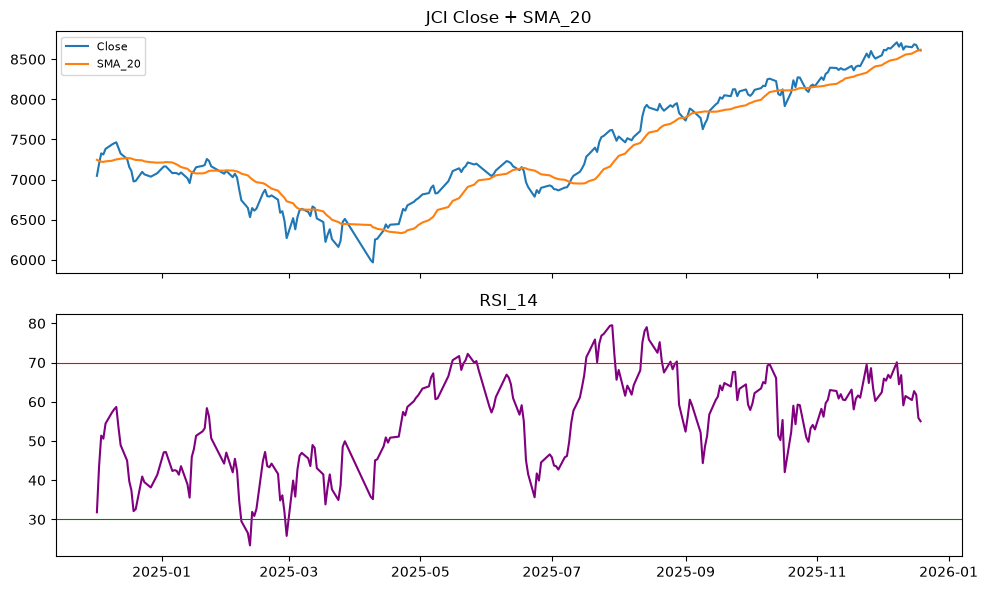

In [5]:
tail = df.tail(250)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax.plot(tail["Date"], tail["Close"], label="Close")
ax.plot(tail["Date"], tail["SMA_20"], label="SMA_20")
ax.legend(fontsize=8)
ax.set_title("JCI Close + SMA_20")
ax2.plot(tail["Date"], tail["RSI_14"], color="purple")
ax2.axhline(70, color="red", linewidth=0.8)
ax2.axhline(30, color="green", linewidth=0.8)
ax2.set_title("RSI_14")
plt.tight_layout()
plt.show()

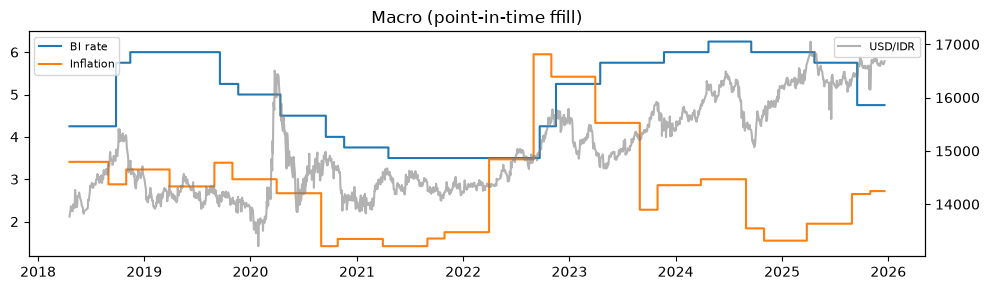

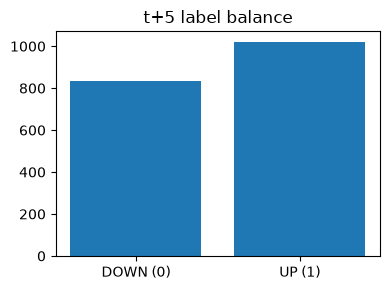

tensor shapes: (1825, 28, 7) (1825, 3) (1825, 64)


In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(df["Date"], df["bi_rate"], label="BI rate")
ax.step(df["Date"], df["inflation_rate"], label="Inflation")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Macro (point-in-time ffill)")
ax2 = ax.twinx()
ax2.plot(df["Date"], df["usd_idr"], color="gray", alpha=0.6, label="USD/IDR")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

counts = df["target_direction"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["DOWN (0)", "UP (1)"], [counts.get(0.0, 0), counts.get(1.0, 0)])
ax.set_title(f"t+{CFG.horizon} label balance")
plt.tight_layout()
plt.show()
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print("tensor shapes:", X_tech.shape, X_macro.shape, X_news.shape)

## Walk-Forward Fold Metrics & Gating Analysis

Per-fold performance, gating weights evolution, ROC curves, confusion matrices, and prediction analysis.

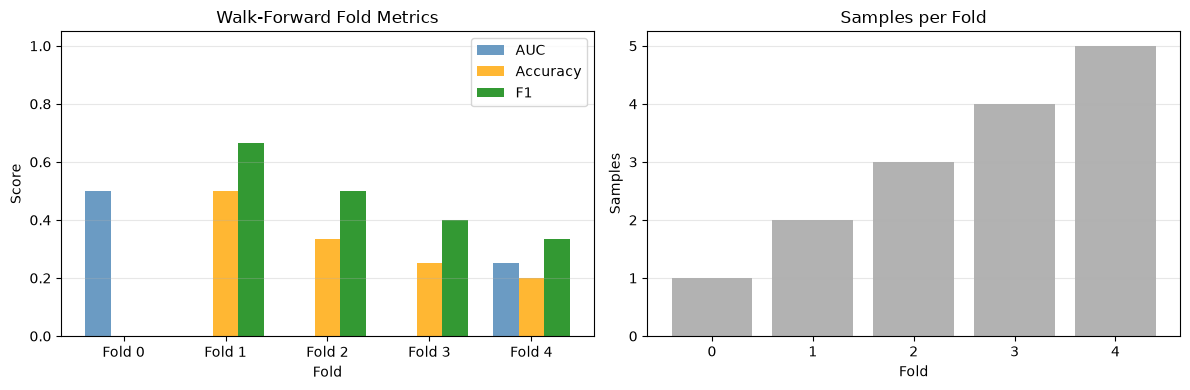

Fold | AUC     | Acc     | F1      | Samples
------|---------|---------|---------|--------
  0   | 0.5000 | 0.0000 | 0.0000 | 1
  1   | 0.0000 | 0.5000 | 0.6667 | 2
  2   | 0.0000 | 0.3333 | 0.5000 | 3
  3   | 0.0000 | 0.2500 | 0.4000 | 4
  4   | 0.2500 | 0.2000 | 0.3333 | 5
Mean  | 0.1500 | 0.2567 | 0.3800


In [7]:
# Fold metrics bar chart
if _HAS_TORCH and wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    folds = [m["fold"] for m in fm]
    aucs = [m["auc"] for m in fm]
    accs = [m["acc"] for m in fm]
    f1s = [m["f1"] for m in fm]
    n_samples = [m["n_samples"] for m in fm]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(folds))
    width = 0.25
    ax1.bar(x - width, aucs, width, label="AUC", color="steelblue", alpha=0.8)
    ax1.bar(x, accs, width, label="Accuracy", color="orange", alpha=0.8)
    ax1.bar(x + width, f1s, width, label="F1", color="green", alpha=0.8)
    ax1.set_xlabel("Fold")
    ax1.set_ylabel("Score")
    ax1.set_title("Walk-Forward Fold Metrics")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"Fold {f}" for f in folds])
    ax1.legend()
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis="y", alpha=0.3)

    # Sample counts
    ax2.bar(folds, n_samples, color="gray", alpha=0.6)
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Samples")
    ax2.set_title("Samples per Fold")
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("Fold | AUC     | Acc     | F1      | Samples")
    print("------|---------|---------|---------|--------")
    for m in fm:
        print(
            f"  {m['fold']}   | {m['auc']:.4f} | {m['acc']:.4f} | {m['f1']:.4f} | {m['n_samples']}"
        )
    avg_auc = np.mean([m["auc"] for m in fm])
    avg_acc = np.mean([m["acc"] for m in fm])
    avg_f1 = np.mean([m["f1"] for m in fm])
    print(f"Mean  | {avg_auc:.4f} | {avg_acc:.4f} | {avg_f1:.4f}")
else:
    print("No fold metrics available for visualization.")

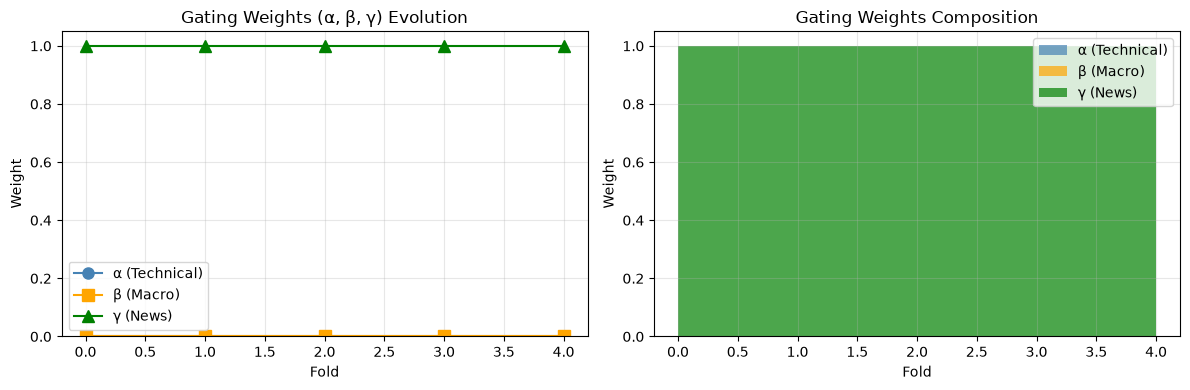

Fold | α (Tech) | β (Macro) | γ (News)
------|----------|-----------|---------
  0   | 0.0000    | 0.0000     | 1.0000
  1   | 0.0000    | 0.0000     | 1.0000
  2   | 0.0000    | 0.0000     | 1.0000
  3   | 0.0000    | 0.0000     | 1.0000
  4   | 0.0000    | 0.0000     | 1.0000
Mean  | 0.0000    | 0.0000     | 1.0000


In [8]:
# Gating weights (α, β, γ) evolution over folds
if _HAS_TORCH and wf_metrics and "weights_list" in wf_metrics:
    weights = np.array(wf_metrics["weights_list"])  # shape: (n_folds, 3)
    folds = wf_metrics.get("fold_indices", list(range(len(weights))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Weights over folds
    ax1.plot(folds, weights[:, 0], "o-", label="α (Technical)", color="steelblue", markersize=8)
    ax1.plot(folds, weights[:, 1], "s-", label="β (Macro)", color="orange", markersize=8)
    ax1.plot(folds, weights[:, 2], "^-", label="γ (News)", color="green", markersize=8)
    ax1.set_xlabel("Fold")
    ax1.set_ylabel("Weight")
    ax1.set_title("Gating Weights (α, β, γ) Evolution")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # Stacked area for composition
    ax2.stackplot(
        folds,
        weights[:, 0],
        weights[:, 1],
        weights[:, 2],
        labels=["α (Technical)", "β (Macro)", "γ (News)"],
        colors=["steelblue", "orange", "green"],
        alpha=0.7,
    )
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Weight")
    ax2.set_title("Gating Weights Composition")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Fold | α (Tech) | β (Macro) | γ (News)")
    print("------|----------|-----------|---------")
    for i, w in enumerate(weights):
        print(f"  {folds[i]}   | {w[0]:.4f}    | {w[1]:.4f}     | {w[2]:.4f}")
    avg_w = weights.mean(axis=0)
    print(f"Mean  | {avg_w[0]:.4f}    | {avg_w[1]:.4f}     | {avg_w[2]:.4f}")
else:
    print("No gating weights available for visualization.")

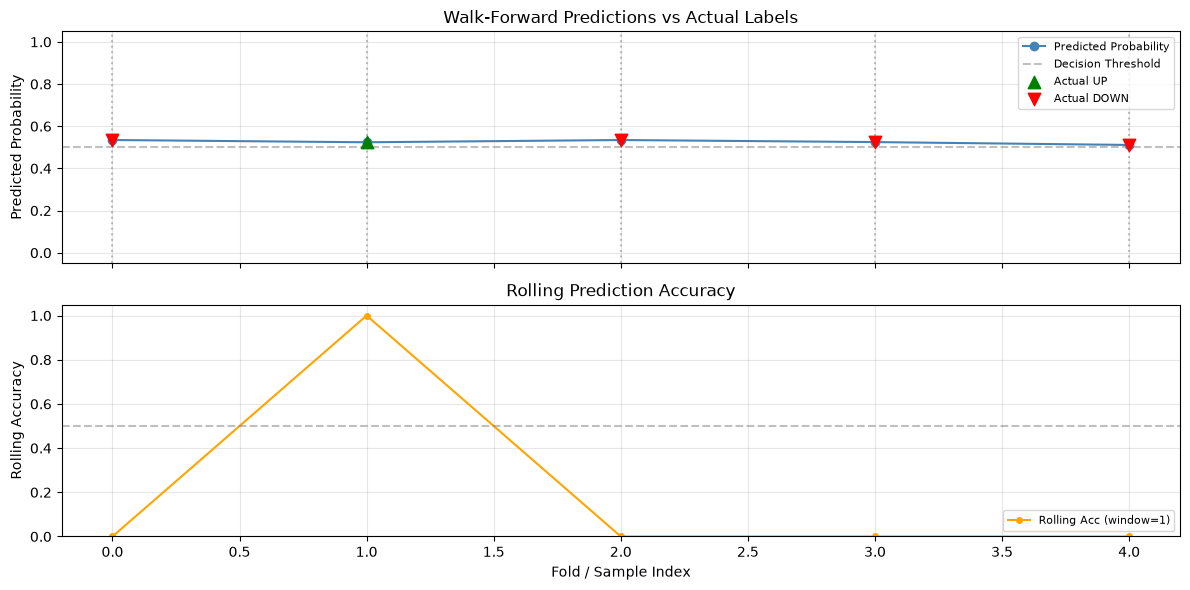

In [9]:
# Prediction vs Actual timeline
if _HAS_TORCH and wf_metrics and "preds" in wf_metrics:
    preds = wf_metrics["preds"]
    truths = wf_metrics["truths"]
    fold_indices = wf_metrics.get("fold_indices", list(range(len(preds))))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    x = np.arange(len(preds))

    # Predictions with actual markers
    ax1.plot(x, preds, "o-", color="steelblue", label="Predicted Probability", markersize=6)
    ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Decision Threshold")
    # Mark actual labels
    up_idx = [i for i, t in enumerate(truths) if t == 1.0]
    down_idx = [i for i, t in enumerate(truths) if t == 0.0]
    ax1.scatter(
        up_idx,
        [preds[i] for i in up_idx],
        color="green",
        s=80,
        marker="^",
        label="Actual UP",
        zorder=5,
    )
    ax1.scatter(
        down_idx,
        [preds[i] for i in down_idx],
        color="red",
        s=80,
        marker="v",
        label="Actual DOWN",
        zorder=5,
    )
    # Fold boundaries
    if "fold_indices" in wf_metrics and len(wf_metrics["fold_indices"]) > 1:
        for fi in wf_metrics["fold_indices"]:
            if fi < len(preds):
                ax1.axvline(fi, color="gray", linestyle=":", alpha=0.5)
    ax1.set_ylabel("Predicted Probability")
    ax1.set_title("Walk-Forward Predictions vs Actual Labels")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.05, 1.05)

    # Accuracy over time (rolling)
    pred_labels = [1 if p > 0.5 else 0 for p in preds]
    rolling_acc = []
    window = max(1, len(preds) // 5)
    for i in range(len(preds)):
        start = max(0, i - window + 1)
        rolling_acc.append(np.mean([pred_labels[j] == truths[j] for j in range(start, i + 1)]))
    ax2.plot(
        x, rolling_acc, "o-", color="orange", label=f"Rolling Acc (window={window})", markersize=4
    )
    ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Fold / Sample Index")
    ax2.set_ylabel("Rolling Accuracy")
    ax2.set_title("Rolling Prediction Accuracy")
    ax2.legend(loc="lower right", fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()
else:
    print("No predictions available for visualization.")

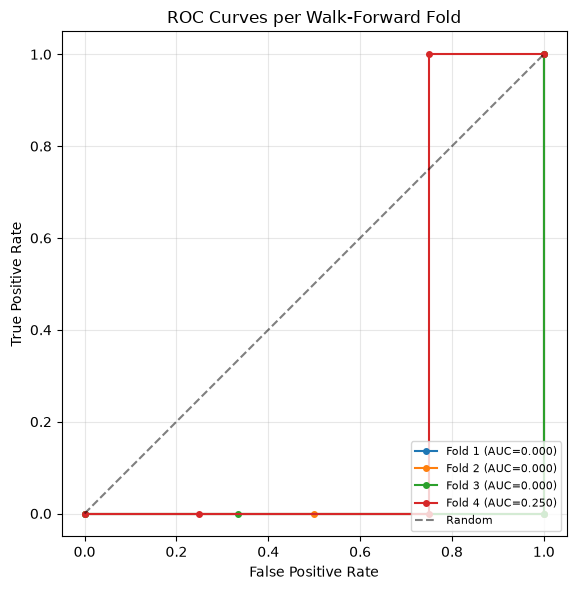

In [10]:
# ROC curves per fold
if _HAS_TORCH and wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    fig, ax = plt.subplots(figsize=(6, 6))

    from sklearn.metrics import roc_curve

    for m in fm:
        if "preds" in m and "truths" in m and len(set(m["truths"])) > 1:
            fpr, tpr, _ = roc_curve(m["truths"], m["preds"])
            fold_auc = m["auc"]
            ax.plot(fpr, tpr, "o-", label=f"Fold {m['fold']} (AUC={fold_auc:.3f})", markersize=4)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves per Walk-Forward Fold")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for ROC curves.")

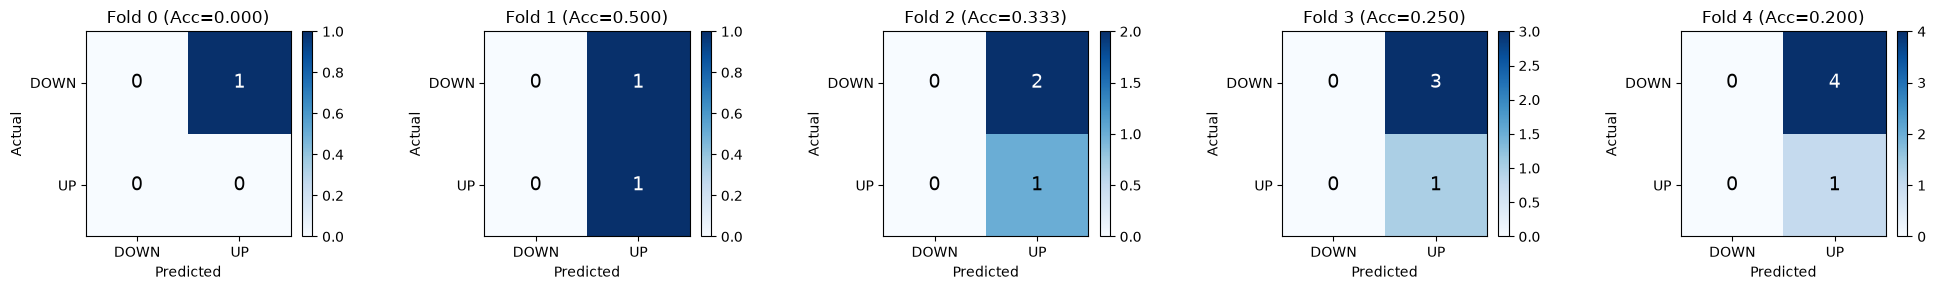

In [11]:
from sklearn.metrics import confusion_matrix

if _HAS_TORCH and wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    n_folds = len(fm)
    fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 3))
    if n_folds == 1:
        axes = [axes]

    for idx, m in enumerate(fm):
        ax = axes[idx]
        pred_labels = [1 if p > 0.5 else 0 for p in m["preds"]]
        truths = m["truths"]
        cm = confusion_matrix(truths, pred_labels, labels=[0, 1])
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
        ax.set_title(f"Fold {m['fold']} (Acc={m['acc']:.3f})")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["DOWN", "UP"])
        ax.set_yticklabels(["DOWN", "UP"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        # Annotate
        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print("No fold data for confusion matrices.")

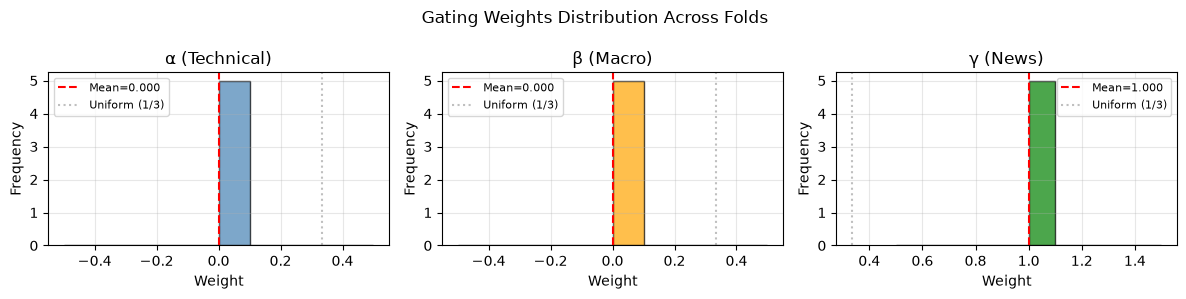

Weight | Mean    | Std     | Min     | Max
-------|---------|---------|---------|---------
α (Technical) | 0.0000 | 0.0000 | 0.0000 | 0.0000
β (Macro)    | 0.0000 | 0.0000 | 0.0000 | 0.0000
γ (News)     | 1.0000 | 0.0000 | 1.0000 | 1.0000


In [12]:
# Gating weights distribution histograms
if _HAS_TORCH and wf_metrics and "weights_list" in wf_metrics:
    weights = np.array(wf_metrics["weights_list"])

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    labels = ["α (Technical)", "β (Macro)", "γ (News)"]
    colors = ["steelblue", "orange", "green"]

    for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
        ax.hist(weights[:, i], bins=10, color=color, alpha=0.7, edgecolor="black")
        ax.axvline(
            weights[:, i].mean(),
            color="red",
            linestyle="--",
            label=f"Mean={weights[:, i].mean():.3f}",
        )
        ax.axvline(1 / 3, color="gray", linestyle=":", alpha=0.5, label="Uniform (1/3)")
        ax.set_xlabel("Weight")
        ax.set_ylabel("Frequency")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Gating Weights Distribution Across Folds")
    plt.tight_layout()
    plt.show()

    # Statistics
    print("Weight | Mean    | Std     | Min     | Max")
    print("-------|---------|---------|---------|---------")
    for i, label in enumerate(["α (Technical)", "β (Macro)", "γ (News)"]):
        w = weights[:, i]
        print(f"{label:12s} | {w.mean():.4f} | {w.std():.4f} | {w.min():.4f} | {w.max():.4f}")
else:
    print("No gating weights for distribution visualization.")

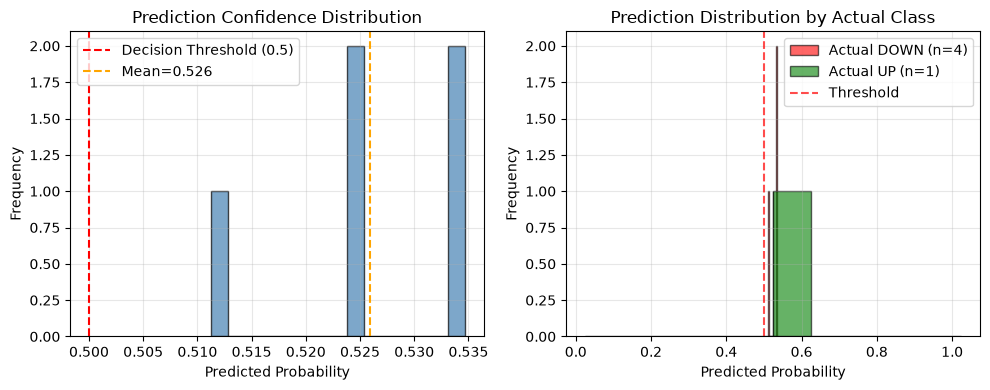

Overall: mean=0.5259, std=0.0086
DOWN actual: n=4, mean=0.5264, std=0.0096
UP actual:   n=1, mean=0.5240, std=0.0000
UP recall (pred>0.5): 1.0000
DOWN recall (pred<0.5): 0.0000


In [13]:
# Prediction confidence histogram
if _HAS_TORCH and wf_metrics and "preds" in wf_metrics:
    preds = np.array(wf_metrics["preds"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Overall distribution
    ax1.hist(preds, bins=15, color="steelblue", alpha=0.7, edgecolor="black")
    ax1.axvline(0.5, color="red", linestyle="--", label="Decision Threshold (0.5)")
    ax1.axvline(preds.mean(), color="orange", linestyle="--", label=f"Mean={preds.mean():.3f}")
    ax1.set_xlabel("Predicted Probability")
    ax1.set_ylabel("Frequency")
    ax1.set_title("Prediction Confidence Distribution")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # By actual class
    truths = np.array(wf_metrics["truths"])
    up_preds = preds[truths == 1.0]
    down_preds = preds[truths == 0.0]

    ax2.hist(
        down_preds,
        bins=10,
        alpha=0.6,
        label=f"Actual DOWN (n={len(down_preds)})",
        color="red",
        edgecolor="black",
    )
    ax2.hist(
        up_preds,
        bins=10,
        alpha=0.6,
        label=f"Actual UP (n={len(up_preds)})",
        color="green",
        edgecolor="black",
    )
    ax2.axvline(0.5, color="red", linestyle="--", alpha=0.7, label="Threshold")
    ax2.set_xlabel("Predicted Probability")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Prediction Distribution by Actual Class")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"Overall: mean={preds.mean():.4f}, std={preds.std():.4f}")
    print(
        f"DOWN actual: n={len(down_preds)}, mean={down_preds.mean():.4f}, std={down_preds.std():.4f}"
    )
    print(f"UP actual:   n={len(up_preds)}, mean={up_preds.mean():.4f}, std={up_preds.std():.4f}")
    # Calibration: fraction of UP actual above 0.5
    if len(up_preds) > 0:
        print(f"UP recall (pred>0.5): {(up_preds > 0.5).mean():.4f}")
    if len(down_preds) > 0:
        print(f"DOWN recall (pred<0.5): {(down_preds < 0.5).mean():.4f}")
else:
    print("No predictions for confidence visualization.")

## Checks

Shapes, finiteness, binary labels, and proof the scalers saw the train prefix only.

In [14]:
assert X_tech.shape[1:] == (lb, len(CFG.tech_cols))
assert len(y) == n_win
assert np.isfinite(X_tech).all() and np.isfinite(X_macro).all()
assert set(np.unique(y)) <= {0.0, 1.0}
raw_tech = df[list(CFG.tech_cols)].values.astype(np.float32)
assert np.allclose(feat_scaler.data_min_, raw_tech[:train_end_df].min(axis=0))

if _HAS_TORCH and model is not None:
    assert all(hasattr(model, a) for a in ("lstm", "mlp", "news_proj", "gate"))
    assert model.lstm.hidden_size == CFG.lstm_dim
    assert model.mlp[-2].out_features == 16
    assert model.news_proj.out_features == CFG.lstm_dim
    assert model.gate.out_features == CFG.fusion_output_dim
    assert CFG.fusion_input_dim == CFG.lstm_dim + 16 + CFG.lstm_dim
    if metrics and "prob" in metrics:
        assert "prob" in metrics
        assert "auc" in wf_metrics and "acc" in wf_metrics and "f1" in wf_metrics
    print("OK: thesis model architecture verified")

print("OK: leak-free single-notebook run passed")

OK: thesis model architecture verified
OK: leak-free single-notebook run passed
